In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("parallel_regret_data.csv")

In [5]:
data.head()

,fen,ref_nodes,ref_bestmove,ref_root_score_type,ref_root_score_value,bucket_50000_bestmove,bucket_200000_bestmove,bucket_800000_bestmove,bucket_50000_regret_cp,bucket_200000_regret_cp,bucket_800000_regret_cp,label_bucket
0,r1b2rk1/1p2pp1p/p2p1npQ/q1pN2N1/P3P3/3P2PP/1P2...,1600000,c8g4,mate,6,c8g4,c8g4,c8g4,0,0,0,50000
1,6k1/5pp1/3R3p/4p3/P2n4/3r2P1/3r1PKP/R2N4 w - -,1600000,a4a5,cp,-336,a4a5,a4a5,a4a5,0,0,0,50000
2,r2q1rk1/ppp2ppp/2np1n2/2b1p3/4P1b1/1BPP1N2/PP3...,1600000,h2h3,cp,31,h2h3,h2h3,h2h3,0,0,0,50000
3,r2q1rk1/pp1nbppp/2p1pn2/3p1b2/2PP1B2/2N1PN2/PP...,1600000,f3d2,cp,32,f3d2,f3d2,f3d2,0,0,0,50000
4,r3kb1r/ppp2ppp/2np2q1/4PbB1/3p4/P2B1N2/1PP2PPP...,1600000,e5d6,cp,-104,e5d6,e5d6,e5d6,0,0,0,50000


In [6]:
cp_diff_cols = [c for c in data.columns if c.endswith("_regret_cp")]
cp_diff_cols

['bucket_50000_regret_cp',
 'bucket_200000_regret_cp',
 'bucket_800000_regret_cp']

In [7]:
summary = data[cp_diff_cols].describe().T
summary[["count", "mean", "50%", "std", "min", "max"]]

,count,mean,50%,std,min,max
bucket_50000_regret_cp,1000.0,9.995,0.0,222.789327,0.0,6954.0
bucket_200000_regret_cp,1000.0,11.004,0.0,225.250678,0.0,6954.0
bucket_800000_regret_cp,1000.0,14.639,0.0,281.866709,0.0,6954.0


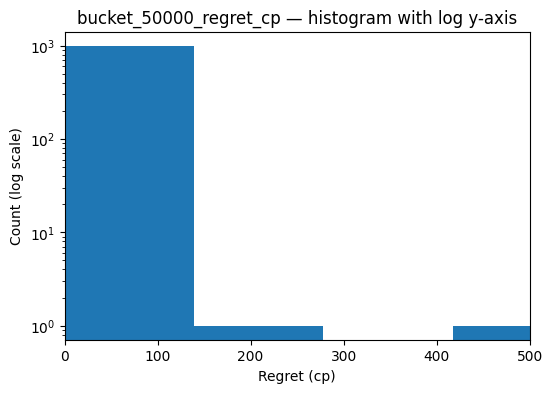

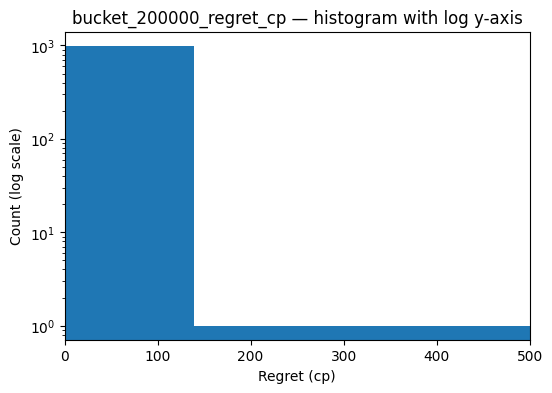

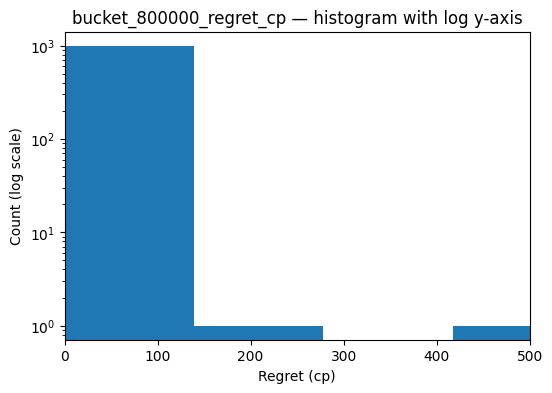

In [17]:
for col in cp_diff_cols:
    vals = data[col].dropna()

    plt.figure(figsize=(6,4))
    plt.hist(vals, bins=50, log=True)
    plt.xlim(0, 500)   # adjust as needed
    plt.xlabel("Regret (cp)")
    plt.ylabel("Count (log scale)")
    plt.title(f"{col} — histogram with log y-axis")
    plt.show()

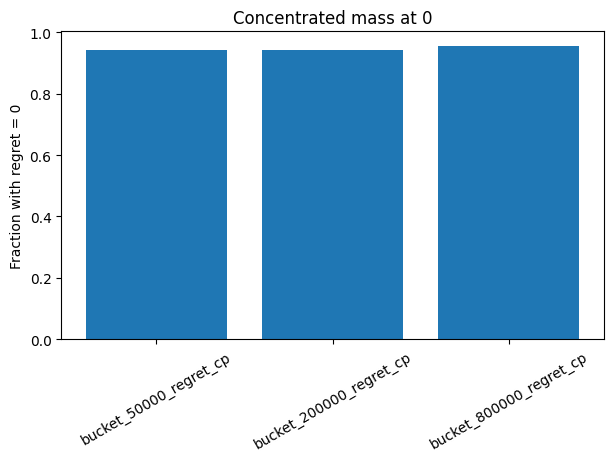

In [12]:
zero_mass = [(data[col] == 0).mean() for col in cp_diff_cols]

plt.figure(figsize=(7,4))
plt.bar(cp_diff_cols, zero_mass)
plt.ylabel("Fraction with regret = 0")
plt.title("Concentrated mass at 0")
plt.xticks(rotation=30)
plt.show()

In [20]:
thresholds = [0, 10, 20, 50, 100]

rows = []
for t in thresholds:
    row = {"threshold_cp": t}
    for col in cp_diff_cols:
        row[col] = (data[col] <= t).mean()
    rows.append(row)

success_table = pd.DataFrame(rows)
success_table

,threshold_cp,bucket_50000_regret_cp,bucket_200000_regret_cp,bucket_800000_regret_cp
0,0,0.941,0.943,0.955
1,10,0.968,0.967,0.979
2,20,0.978,0.980,0.987
3,50,0.987,0.990,0.992
4,100,0.994,0.993,0.995


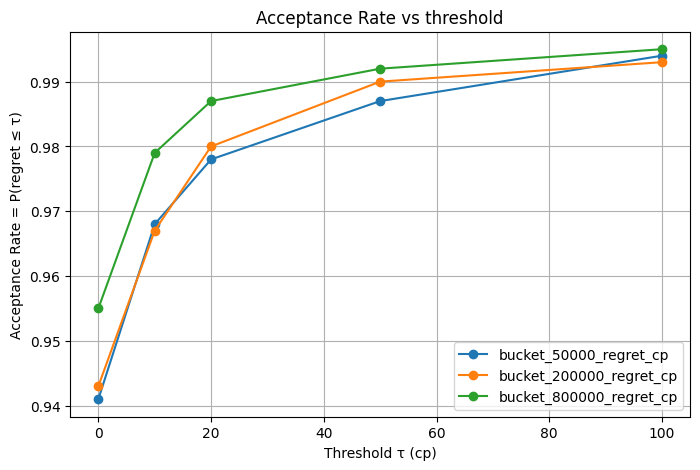

In [22]:

plt.figure(figsize=(8,5))

for col in cp_diff_cols:
    plt.plot(success_table["threshold_cp"], success_table[col], marker="o", label=col)

plt.xlabel("Threshold τ (cp)")
plt.ylabel("Acceptance Rate = P(regret ≤ τ)")
plt.title("Acceptance Rate vs threshold")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
medians = data[cp_diff_cols].median()
means = data[cp_diff_cols].mean()

print("Median:\n", medians)
print("\nMean:\n", means)

Median:
 bucket_50000_regret_cp     0.0
bucket_200000_regret_cp    0.0
bucket_800000_regret_cp    0.0
dtype: float64

Mean:
 bucket_50000_regret_cp      9.995
bucket_200000_regret_cp    11.004
bucket_800000_regret_cp    14.639
dtype: float64


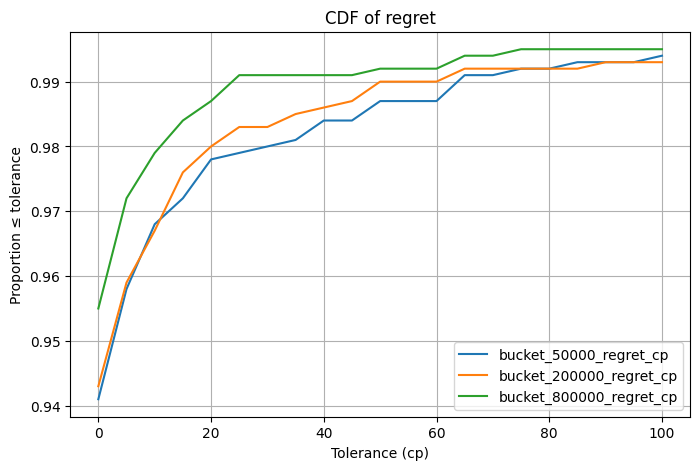

In [11]:
tolerances = np.arange(0, 101, 5)

plt.figure(figsize=(8,5))

for col in cp_diff_cols:
    vals = data[col].dropna().clip(0, 200)
    
    proportions = [(vals <= t).mean() for t in tolerances]
    
    plt.plot(tolerances, proportions, label=col)

plt.xlabel("Tolerance (cp)")
plt.ylabel("Proportion ≤ tolerance")
plt.title("CDF of regret")
plt.legend()
plt.grid()
plt.show()